In [ ]:
include("CRD_STA.jl")
include("Fun.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using PyCall

In [130]:
N_cheb = 69
Mr = 0.3
gamma = 1.4
sigma = 0.72
Ro = - 1
Co = 2 - Ro - Ro ^ 2
Tw = 1
R = 500
Ma = Mr/R
omega = 0
be_ini = 0.125
c = 0.65
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co);
H,T = T_ca(Mr,f,q,w0,gamma,Tw);
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim");
lam = - (2/3) * T;
kappa = (1/sigma) * T;
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
eigval

1-element Vector{ComplexF64}:
 0.6170758211364454 + 0.0004071697924454778im

In [131]:
vel_1 = para_comp(eigvec,N_cheb)

(u = ComplexF64[-0.00015335425339367057 - 0.0002723092296561088im; -0.0006111563705900841 - 0.0011099736089020644im; … ; 1.0060106099688416e-7 - 4.771393967266131e-7im; 2.0724328507342844e-8 + 5.6643820800072325e-8im;;], v = ComplexF64[7.056840650594854e-5 + 0.00010237106891681407im; 0.00028133729523221746 + 0.00040603289847592774im; … ; -3.3821591615498985e-7 - 4.4894332595175543e-7im; -1.1003416619655305e-7 - 1.0914103874132275e-7im;;], w = ComplexF64[-0.0003534773898759428 + 5.0770972399925667e-5im; -1.4176967194922581e-6 + 7.856353633041782e-7im; … ; -4.0710848273524635e-7 - 6.149917900983085e-7im; 2.460326665387485e-8 + 3.8714948860912174e-8im;;], p = ComplexF64[1.069200706772444e-7 + 1.4790350475590158e-6im; 4.2275494704301423e-7 + 5.9221548103372944e-6im; … ; 1.4068671717030294e-13 - 2.867299670264445e-11im; -7.195281809344474e-13 + 9.74926086041994e-13im;;], T = ComplexF64[-1.0466272861251701e-7 - 1.4791413205550615e-6im; -4.217580134837086e-7 - 5.92275129990532e-6im; … ; -3.62

In [132]:
energy_1 = abs.((vel_1.u.^2 + vel_1.v.^2 + vel_1.w.^2))/2
energy_2 = abs.((vel_2.u.^2 + vel_2.v.^2 + vel_2.w.^2))/2

68×1 Matrix{Float64}:
 3.076092121771962e-7
 8.986617163427165e-7
 4.50791555909798e-6
 1.4476594831221209e-5
 3.54795084264641e-5
 7.410798179763837e-5
 0.00013829119311248124
 0.00023776138850244708
 0.0003843958428855108
 0.0005911871692756628
 ⋮
 6.977757672128061e-6
 4.459144245242001e-6
 3.050987431010858e-6
 1.3883104307349737e-6
 4.79369896851544e-7
 2.3703001654292808e-8
 1.616186724213552e-9
 3.5136445019524217e-10
 1.2944150661953496e-9

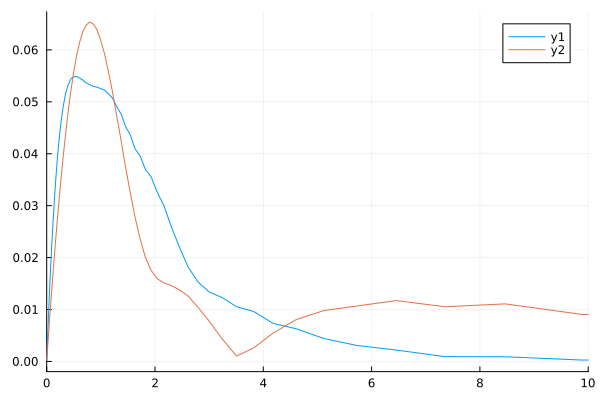

In [143]:
plot(x[2:end-1,1],abs.(vel_1.u),xlims = [0,10])
plot!(x[2:end-1,1],abs.(vel_2.u)) 

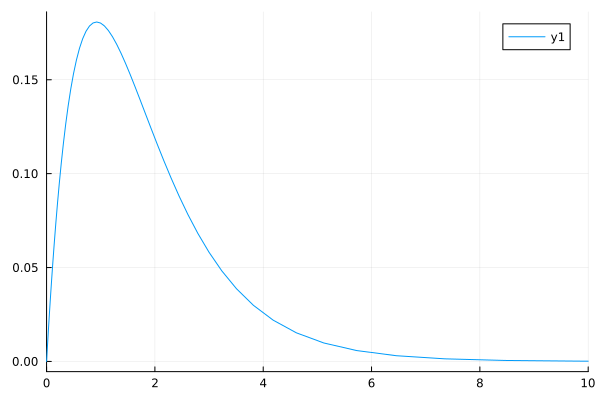

In [137]:
plot(x,F,xlims=[0,10])

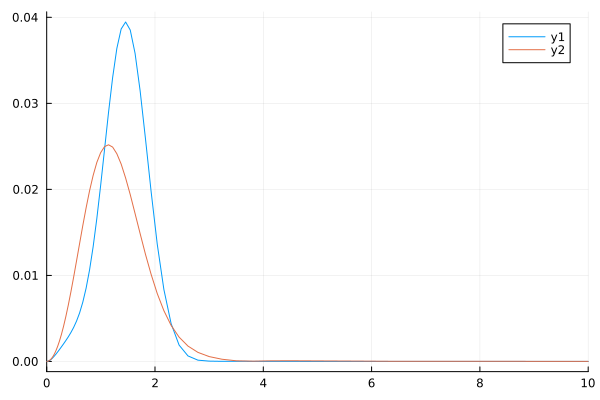

In [138]:
plot(x[2:end-1,1],energy_1,xlims = [0,10])
plot!(x[2:end-1,1],energy_2)

In [ ]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,z,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c)
    sigma = 0.72
    gamma = 1.4
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
    eigval = conj(eigval)
    return eigval
end

In [ ]:
##DIRECTLY CACULATE CUR
##initial
# for omega = [0.048,0.024,-0.024,-0.048]
function cur(Tw,Mr,Ro,omega,R_ini)

    N_cheb = 69
    gamma = 1.4
    sigma = 0.72
    R_ini = 200
    R_step = 0.4
    be_ini = 0.04
    be_step = -0.0008
    num = 1
    c_ini = 0.06
    Co = 2-Ro-Ro^2
    Ma = Mr/R_ini
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    initial = []
    tempvec = [0 0 0 0 0]
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini)
    if imag(eigval[1]) < 0
        for be = be_ini : be_step : 0
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini)
            point = filter(x -> abs(imag(x)) < 0.0005 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [omega R_ini be real(point) imag(point)]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : -be_step : 0.5
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini)
            point = filter(x ->  - 0.0005 < imag(x) < 0.0005, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [omega R_ini be real(point) imag(point)]
                break
            end
        end
    end
    total = initial

 # CACULATE

    for be = initial[end,3] +  be_step  :  -1 * be_step : 0.4

        # if total_i[end,2] <40
        #     num = 5
        # else
        #     num = 1
        # end
        num = 1

        c = total[end,4] - im * total[end,5]
        eigval_1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be+2*be_step,N_cheb,Ro,Co,D,D2,c)
        eigval_2 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be-2*be_step,N_cheb,Ro,Co,D,D2,c)

        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

            mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

            mode = 2

        end
        
        if mode == 1 



            for R = total[end,2] : R_step : 600

                Ma = Mr/R

                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    
                    break
                end
                
                if len > 25 && abs(tempvec[end,5]) > abs(tempvec[end-10,5])

                    mode = 2
                    tempvec = [0 0 0 0 0]
                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0

                Ma = Mr/R
                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    
                    break
                end
                
                if len > 25 && abs(tempvec[end,5]) > abs(tempvec[end-10,5])

                    mode = 1
                    tempvec = [0 0 0 0 0]
                    break
                end
            end        
        end

        if mode == 1
            
            for R = total[end,2]: R_step : 600
                Ma = Mr/R

                if total[end,3] == be

                    break

                end 

                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    
                    break
                end
                
                if len > 25 && abs(tempvec[end,5]) > abs(tempvec[end-10,5])

                    mode = 2
                    tempvec = [0 0 0 0 0]
                    break
                end
            end        
        end

        if total[end,2] > R_ini + 10 && size(total,1)>40
            break
        end
    end
    writedlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat",total)
 end

cur (generic function with 1 method)

In [13]:
cur(1,0.3,0.687,0,200)

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/MEH0d/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/MEH0d/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/MEH0d/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/MEH0d/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/MEH0d/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/MEH0d/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/MEH0d/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

InterruptException: InterruptException: